In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import pickle
from forager import forager
from space import space 
import seaborn as sns
import random
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

In [2]:
cond = 1
env = space(cond)
env.make_trajectories()
env.recog_trials()
event_shifts = env.event_shifts()

In [3]:
def get_event_type(event_shifts,planet):
    event_type = np.searchsorted(event_shifts,planet,side='right')
    return event_type

In [4]:
def forage(forager_num,env,threshold,eff,df):
    # df - dataframe to fill 
    # threshold high or low
    mem_ability = np.random.uniform(0.7,0.9) # randomly select a memory ability
    stay_policy = np.random.uniform(30,40) # randomly select a stay policy 
    if threshold == 'high':
        f = forager(30,10,stay_policy,mem_ability,eff)
    else:
        f = forager(10,10,stay_policy,mem_ability,eff)
    
    n_blocks = len(env.trajectories)
    n_planets = len(env.trajectories[0]) # number of planets in block 
    planet = 0

    for b in range(n_blocks):
        for p in range(n_planets):
            planet += 1
            f.memory['planet_'+str(planet)] = f.curr_event
            curr_planet = env.trajectories[b][p] # grab the trajectory for the current planet 
            prt = 0
            curr_r = curr_planet[prt] # forager has to do the first dig 
            while curr_r > f.stay_policy: # while the current reward per dig is greater than forager's threshold
                prt += 1
                # make a prediction of how much it's gonna decay 
                pred = curr_r*f.make_prediction(planet)
                # dig again 
                curr_r = curr_planet[prt] # observe a reward
                rpe = abs(curr_r - pred) # prediction error
                decay = curr_r/curr_planet[prt-1] # detrmine how much it decayed
                # determine if need to segment or not and update repesentation
                f.segment(planet,decay, rpe)
        # at the end of the block, do the recall 
        curr_block_recog = env.recog_trials[b]
        for trial in range(len(curr_block_recog)):
            planet_1 = curr_block_recog[trial][0]
            planet_2 = curr_block_recog[trial][1]
            
            between = (get_event_type(event_shifts[b],planet_1))== (get_event_type(event_shifts[b],planet_2))
        
            correct = f.sequence_recall(planet_1,planet_2)
            actual_dist = abs(planet_1 - planet_2) - 1
            dist_judg = f.dist_judge(planet_1,planet_2)
        
            row = pd.DataFrame({'forager':forager_num,'thresh_group':threshold,'eff_size':eff,'block':b,'trial':trial,'between':between,'actual_dist':actual_dist,'seq_mem':correct,
                            'dist_judg':dist_judg},index=[0])
            df = pd.concat([df,row],ignore_index=True)
    return df

In [5]:
df=pd.DataFrame(columns=['forager','thresh_group','eff_size','block','trial','between','actual_dist','seq_mem','dist_judg'])
all_eff_size = [1.3,1.5,1.8]

for eff_size in all_eff_size:
    print(eff_size)
    for sub in range(1000):
        print(sub)
        if sub%2 == 0: # if even assign to the high threshold group, otherwise low
            threshold = 'high'
        else:
            threshold = 'low'
        df = forage(sub,env,threshold,eff_size,df)
    

1.3
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
27

128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316
317
318
319
320
321
322
323
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
342
343
344
345
346
347
348
349
350
351
352
353
354
355
356
357
358
359
360
361
362
363
364
365
366
367
368
369
370
371
372
373
374
375
376
377


In [6]:
with open('../pickled_exp_parms/max_h_cond_'+str(cond)+'_power_sim.pkl','wb') as f:
    pickle.dump([df],f)

In [7]:
df = df.replace([1.3,1.5,1.8], ['small','med','large'])

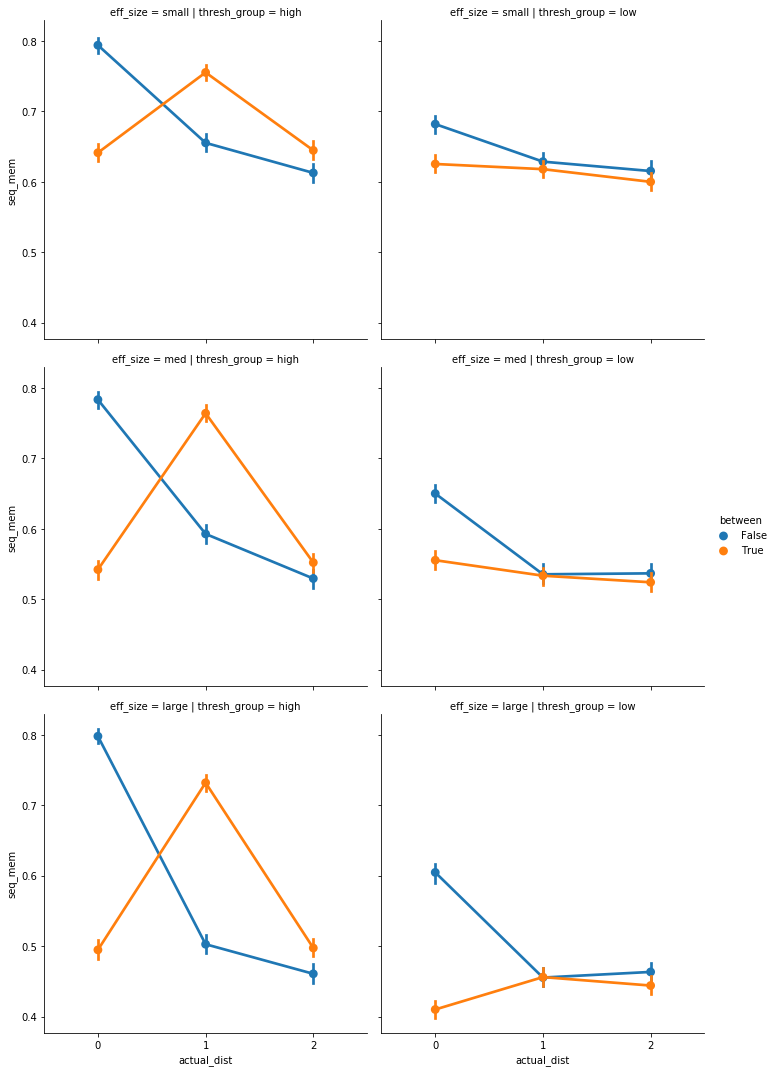

In [8]:
sns.catplot(y="seq_mem",x="actual_dist",hue="between",col="thresh_group", kind="point",ci=68,data=df,row="eff_size")
plt.savefig('../plots/max_h_cond_'+str(cond)+'_seq_memory.png')

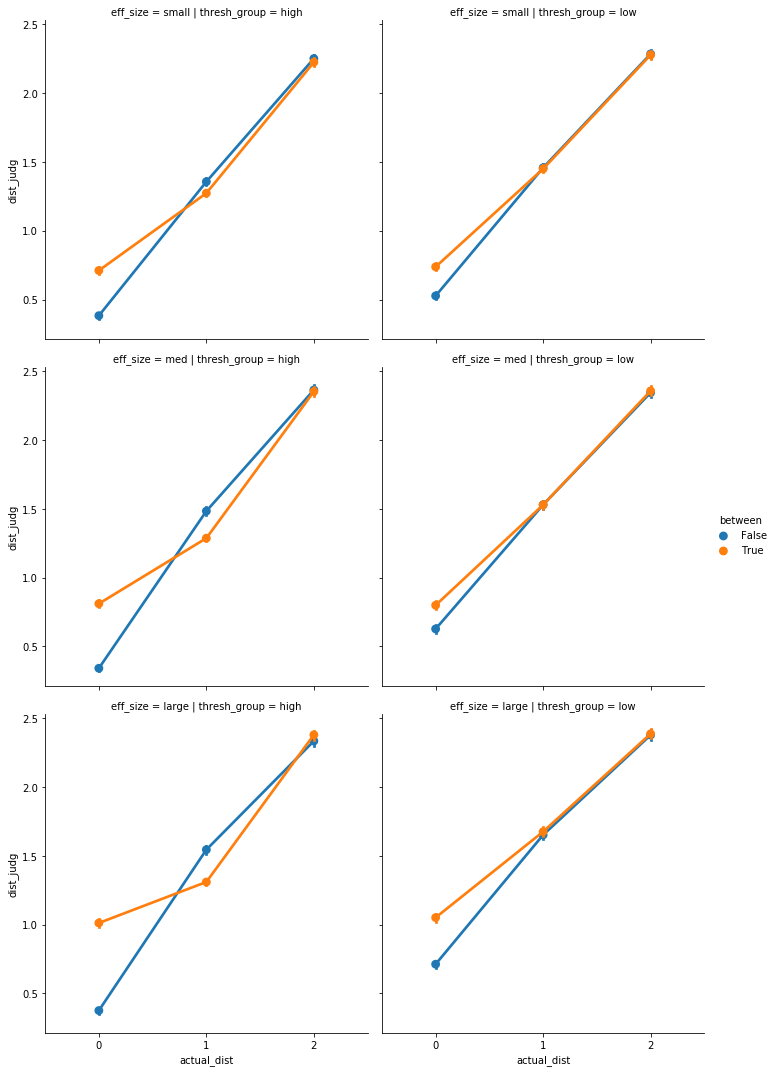

In [9]:
sns.catplot(y="dist_judg",x="actual_dist",hue="between",col="thresh_group", kind="point",row="eff_size",ci=68,data=df)
plt.savefig('../plots/max_h_cond_'+str(cond)+'_dist_judg.png')

In [10]:
# between group effect 
stats.ttest_ind(df.loc[(df["thresh_group"]=="high")&(df["between"]==1)]["seq_mem"],df.loc[(df["thresh_group"]=="low")&(df["between"]==1)]["seq_mem"])

Ttest_indResult(statistic=15.916161008220989, pvalue=8.876730011518166e-57)

In [ ]:
# To do:
# look at memory effect size need to detect the difference between 30 and 10
# look at memory effect size need to detect the difference between 50 and 30
# look at memory effect size need to detect the difference between 50 and 10

# do this for each condition - 5 plots- with 4 data points on x axis 

In [11]:
def cohen_d(x,y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

In [12]:
df = df.replace(['small','med','large'],[1.3,1.5,1.8])

In [13]:
# use effect size to figure out sample size needed for 80% power and p <0.05
df_power = pd.DataFrame(columns=['eff_size','ratio','n']) # construct a dataframe that says what's the necessary sample size to detect an effect w/ these params

for eff_size in all_eff_size:
    effect_size = cohen_d(df.loc[(df["thresh_group"]=="high")&(df["between"]==1)&(df["eff_size"]==eff_size)]["seq_mem"],df.loc[(df["thresh_group"]=="low")&(df["between"]==1)&(df["eff_size"]==eff_size)]["seq_mem"])

    ratios = [0.05,0.1,0.5,1] # ratio of first group to second group, don't know the prevalence of this will be so sill simulate over a wide range

    power = 0.80
    alpha = 0.05
    analysis = TTestIndPower()

    for ratio in ratios:
        # dependent on how much we sample each group relative to one another so we'll calculate for a large range of possibilities (0.05,0.1,0.5,1)
        result = analysis.solve_power(effect_size,power=power,nobs1=None,ratio=ratio,alpha=alpha)
        row = pd.DataFrame({'eff_size':eff_size,'ratio':ratio,'n':result},index=[0])
        df_power = pd.concat([df_power,row],ignore_index=True)

In [14]:
df_power = df_power.replace([1.3,1.5,1.8], ['small','med','large'])

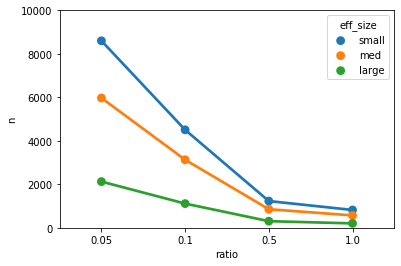

In [16]:
sns.pointplot(x="ratio",y="n",hue='eff_size',data=df_power)
plt.ylim([0,10000])

plt.savefig('../plots/max_h_cond_'+str(cond)+'_sample_size.png')

In [17]:
df_power

,eff_size,ratio,n
0,small,0.05,8599.637021
1,small,0.10,4505.360168
2,small,0.50,1229.539992
3,small,1.00,819.800267
4,med,0.05,5971.912641
5,med,0.10,3128.933316
6,med,0.50,854.151348
7,med,1.00,569.541273
8,large,0.05,2124.571416
9,large,0.10,1113.660552
